In [1]:
%load_ext autoreload
%autoreload 2

import logging
from datetime import datetime, timedelta
from pathlib import Path
from typing import Literal

import geopandas as gpd
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import colors as mcolors
from matplotlib import pyplot as plt
from matplotlib.axes import Axes
from matplotlib.colors import Normalize
from PIL import Image

from ppcluster import load_config, setup_logger

%matplotlib widget

# --- Default patterns (override via function arguments) ---
_DEFAULT_INPUT_DIR_PATTERN = "output/{year}_PPCX_Tele"
_DEFAULT_IMG_DIR_PATTERN = (
    "/mnt/irpinas/planpincieux/ppcx_dic/data/{year}/coregistration/coregistered/"
)
_DEFAULT_IMG_DATE_FMT = "%Y_%m_%d"
_DEFAULT_IMG_EXT = "jpg"

date = "2020-08-01"
date_prev_dt_days = 7

logger = setup_logger(logging.INFO, name="ppcx")

config = load_config()


def resolve_input_dir(
    date: str | datetime,
    dir_pattern: str = _DEFAULT_INPUT_DIR_PATTERN,
) -> Path:
    """Resolve the input directory for a given date using the provided pattern."""
    return Path(dir_pattern.format(year=_parse_date(date).year))


def load_sectors(
    date: str | datetime,
    search_dir: Path,
) -> tuple[gpd.GeoDataFrame, gpd.GeoDataFrame]:
    """Load sector polygon and points GeoDataFrames. Raises if files are missing."""
    return _load_geojson_pair(
        date=date,
        search_dir=search_dir,
        polygon_suffix="_sectors_polygon.geojson",
        points_suffix="_sectors_points.geojson",
    )


def load_anomaly(
    date: str | datetime,
    search_dir: Path,
) -> tuple[gpd.GeoDataFrame | None, gpd.GeoDataFrame | None]:
    """Load anomaly polygon and points. Returns (None, None) if files are missing."""
    try:
        return _load_geojson_pair(
            date=date,
            search_dir=search_dir,
            polygon_suffix="_anomaly_A_polygon.geojson",
            points_suffix="_anomaly_A_points.geojson",
        )
    except FileNotFoundError:
        return None, None


def load_image(
    date: str | datetime,
    img_dir_pattern: str = _DEFAULT_IMG_DIR_PATTERN,
    img_date_fmt: str = _DEFAULT_IMG_DATE_FMT,
    img_ext: str = _DEFAULT_IMG_EXT,
) -> Image.Image:
    """Find the middle image for the given date and return it as a PIL Image."""
    timestamp = _parse_date(date)
    img_dir = Path(img_dir_pattern.format(year=timestamp.year))
    pattern = f"*{timestamp.strftime(img_date_fmt)}*.{img_ext}"
    candidates = sorted(img_dir.glob(pattern), key=lambda p: p.name)
    if not candidates:
        raise FileNotFoundError(
            f"No images found in '{img_dir}' for pattern: {pattern}"
        )
    return Image.open(candidates[len(candidates) // 2])


def find_closest_date_with_sectors(
    date: str | datetime,
    dt_days: int,
    max_search_days: int = 3,
    search_dir_pattern: str = _DEFAULT_INPUT_DIR_PATTERN,
    direction: Literal["closest", "backward", "forward"] = "closest",
) -> tuple[datetime, Path] | None:
    """
    Find the closest date to `date ± dt_days` that has valid sector data.

    Parameters
    ----------
    date : str | datetime
        Reference date.
    search_dir_pattern : str
        Pattern used to resolve the input directory (must contain {year}).
    dt_days : int
        Number of days before/after `date` to start the search (default: 7).
    max_search_days : int
        Maximum number of additional days to search from the start point (default: 30).
    direction : {"closest", "backward", "forward"}
        - "closest" : search in both directions, return the closest valid date.
        - "backward": search from date - dt_days, walking further back.
        - "forward" : search from date + dt_days, walking further forward.

    Returns
    -------
    (found_date, search_dir) : (tuple[datetime, Path] | None)
        The closest valid datetime and its resolved sectors search directory.
        Returns None if no date with valid data is found within max_search_days.
    """
    timestamp = _parse_date(date)

    def _has_sectors(candidate: datetime) -> Path | None:
        candidate_str = candidate.strftime("%Y-%m-%d")
        input_dir = resolve_input_dir(candidate, search_dir_pattern)
        search_dir = input_dir / "kinematic_sectors_geojson"
        polygon = search_dir / f"{candidate_str}_sectors_polygon.geojson"
        points = search_dir / f"{candidate_str}_sectors_points.geojson"
        return search_dir if (polygon.exists() and points.exists()) else None

    def _search(start: datetime, step: int) -> tuple[datetime, Path] | None:
        for offset in range(max_search_days):
            candidate = start + timedelta(days=offset * step)
            search_dir = _has_sectors(candidate)
            if search_dir is not None:
                return candidate, search_dir
        return None

    def _log_not_found(label: str, start: datetime) -> None:
        logger.error(
            f"No valid sector data found {label} (started at {start.date()}, searched {max_search_days} days).",
        )

    if direction == "backward":
        start = timestamp - timedelta(days=dt_days)
        result = _search(start, step=-1)
        if result is None:
            _log_not_found(f"in the {max_search_days} days before", start)
        return result

    if direction == "forward":
        start = timestamp + timedelta(days=dt_days)
        result = _search(start, step=+1)
        if result is None:
            _log_not_found(f"in the {max_search_days} days after", start)
        return result

    # direction == "closest": pick whichever side yields the smallest |delta|
    backward = _search(timestamp - timedelta(days=dt_days), step=-1)
    forward = _search(timestamp + timedelta(days=dt_days), step=+1)
    if backward is None and forward is None:
        _log_not_found(
            f"within {max_search_days} days of ±{dt_days}d around",
            timestamp,
        )
        return None
    if backward is None:
        return forward
    if forward is None:
        return backward

    return min(backward, forward, key=lambda r: abs(r[0] - timestamp))


def _parse_date(date: str | datetime) -> datetime:
    """Normalize a date string or datetime to a datetime object."""
    if isinstance(date, datetime):
        return date
    return datetime.strptime(date, "%Y-%m-%d")


def _load_geojson_pair(
    date: str | datetime,
    search_dir: Path,
    polygon_suffix: str,
    points_suffix: str,
) -> tuple[gpd.GeoDataFrame, gpd.GeoDataFrame]:
    """Resolve and load a polygon + points GeoJSON pair from a pre-resolved directory."""
    date_str = _parse_date(date).strftime("%Y-%m-%d")
    polygon_path = search_dir / f"{date_str}{polygon_suffix}"
    points_path = search_dir / f"{date_str}{points_suffix}"
    for p in (polygon_path, points_path):
        if not p.exists():
            raise FileNotFoundError(f"Required file not found: {p}")
    return gpd.read_file(polygon_path), gpd.read_file(points_path)

In [2]:
timestamp = datetime.strptime(date, "%Y-%m-%d")
data_dir = Path(_DEFAULT_INPUT_DIR_PATTERN.format(year=_parse_date(date).year))
output_dir = data_dir / "bollettino"
sectors_gdf, sectors_points = load_sectors(date, data_dir / "kinematic_sectors_geojson")
anomaly_gdf, anomaly_points = load_anomaly(date, data_dir / "anomaly_A_geojson")
img = load_image(date)

In [3]:
# Find closest date with sector data in the 7 days prior
result = find_closest_date_with_sectors(
    date, dt_days=date_prev_dt_days, direction="backward"
)
if result is None:
    raise FileNotFoundError("No prev data found")

prev_date, prev_search_dir = result
input_dir_prev = resolve_input_dir(prev_date)
sectors_gdf_prev, sectors_points_prev = load_sectors(prev_date, prev_search_dir)

In [4]:
# Velocity thresholds (in px/day):
velocity_thresholds = {
    "A": [10.0, 13.0],  # Low: < 10, Medium: 10-13, High: > 13
    "B": [7.0, 10.0],  # Low: < 7, Medium: 7-10, High: > 10
    "C": [3.0, 8.0],  # Low: < 3, Medium: 3-6, High: >  6
    "D": [3.0, 6.0],  # Low: < 3, Medium: 3-6, High: >  6
}

In [5]:
def compute_velocity_levels(
    sectors_gdf: gpd.GeoDataFrame,
    points_gdf: gpd.GeoDataFrame,
    velocity_thresholds: dict[str, list[float]],
    velocity_col: str = "V",
) -> gpd.GeoDataFrame:
    """
    For each sector, compute the number and fraction of points in each
    velocity level (low / medium / high) based on per-sector thresholds.

    Parameters
    ----------
    sectors_gdf : gpd.GeoDataFrame
        Sector polygons with a 'sector' column.
    points_gdf : gpd.GeoDataFrame
        Points with a 'sector' column and a velocity column.
    velocity_thresholds : dict[str, list[float]]
        Per-sector [low_upper, medium_upper] thresholds.
        Points below low_upper → low, between → medium, above medium_upper → high.
    velocity_col : str
        Column in points_gdf to use as velocity (default: "V").

    Returns
    -------
    gpd.GeoDataFrame
        sectors_gdf with added columns:
        n_low, n_medium, n_high, frac_low, frac_medium, frac_high,
    """
    records = []

    for _, sector_row in sectors_gdf.iterrows():
        sector_id = str(sector_row["sector"])
        pts = points_gdf[points_gdf["sector"] == sector_id][velocity_col].dropna()
        n_total = len(pts)

        if sector_id not in velocity_thresholds or n_total == 0:
            records.append(
                dict(
                    sector=sector_id,
                    pts_low=0,
                    pts_medium=0,
                    pts_high=0,
                    pts_frac_low=None,
                    pts_frac_medium=None,
                    pts_frac_high=None,
                )
            )
            continue

        low_thr, high_thr = velocity_thresholds[sector_id]
        n_low = int((pts < low_thr).sum())
        n_medium = int(((pts >= low_thr) & (pts < high_thr)).sum())
        n_high = int((pts >= high_thr).sum())
        frac_low = n_low / n_total
        frac_medium = n_medium / n_total
        frac_high = n_high / n_total
        records.append(
            dict(
                sector=sector_id,
                pts_low=n_low,
                pts_medium=n_medium,
                pts_high=n_high,
                pts_frac_low=frac_low,
                pts_frac_medium=frac_medium,
                pts_frac_high=frac_high,
            )
        )

    stats_df = pd.DataFrame(records)
    return sectors_gdf.merge(stats_df, on="sector", how="left")


sectors_gdf = compute_velocity_levels(sectors_gdf, sectors_points, velocity_thresholds)


In [6]:
def plot_sectors(
    sectors: gpd.GeoDataFrame,
    img: np.ndarray | None = None,
    velocity_df: pd.DataFrame | gpd.GeoDataFrame | None = None,
    velocity_mode: Literal["quiver", "scatter"] = "quiver",
    sector_colors: dict | None = None,
    velocity_cmap: str | None = None,
    min_cbar: float | None = None,
    max_cbar: float | None = None,
    min_cbar_percentile: float | None = None,
    max_cbar_percentile: float | None = None,
    label_column: str = "sector",
    add_sector_labels: bool = False,
    title: str = "Kinematic Sectors",
    ax: Axes | None = None,
    img_kwargs: dict | None = None,
    quiver_kwargs: dict | None = None,
    scatter_kwargs: dict | None = None,
    sector_kwargs: dict | None = None,
    sector_fill_kwargs: dict | None = None,
    sector_edge_kwargs: dict | None = None,
    label_kwargs: dict | None = None,
) -> tuple[Axes, list[mpatches.Patch] | None]:
    """
    Plot velocity field and overlay sector geometries on a given axis.

    Args:
        sectors: GeoDataFrame with sector geometries and labels.
        img: 2D array for background image.
        velocity_df: DataFrame/Geodataframe with velocity vectors (columns: x, y, u, v, V).
        velocity_mode: 'quiver' or 'scatter' for velocity plotting.
        sector_colors: Dict mapping sector labels to colors.
        velocity_cmap: Colormap for velocity field, ignored if velocity_df is None (default 'Blues').
        min_cbar_percentile: Minimum percentile for velocity colorbar scaling.
        max_cbar_percentile: Maximum percentile for velocity colorbar scaling.
        label_column: Column in sectors GeoDataFrame for labeling.
        add_sector_labels: Whether to add text labels at sector centroids.
        title: Title of the plot.
        ax: Matplotlib Axes to plot on. If None, a new figure and axes are created.
        img_kwargs: Keyword arguments for ax.imshow()
        quiver_kwargs: Keyword arguments for ax.quiver()
        scatter_kwargs: Keyword arguments for ax.scatter()
        sector_kwargs: General keyword arguments for sector plotting (applied to both fill and edge if specialized kwargs not provided)
        sector_fill_kwargs: Specific keyword arguments for sector fill
        sector_edge_kwargs: Specific keyword arguments for sector edges
        label_kwargs: Keyword arguments for ax.text() labels

    Returns:
        The matplotlib Axes object with the plot and the list of legend patches.
    """

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))

    if sector_colors is None:
        sector_colors = {}

    if sectors.empty:
        logger.warning("No sectors to plot.")
        return ax, None, []
    else:
        plt_gdf = sectors.copy()

    # Plot background image if provided
    if img is not None:
        # Default defaults
        img_defaults = {"cmap": "gray"}
        if img_kwargs:
            img_defaults.update(img_kwargs)
        ax.imshow(img, **img_defaults)

    # Plot Velocity field if provided
    if velocity_df is not None and not velocity_df.empty:
        X = velocity_df["x"].to_numpy()
        Y = velocity_df["y"].to_numpy()
        mags = velocity_df["V"].to_numpy()

        # Define default color normalization
        vmin = float(np.min(mags))
        vmax = float(np.max(mags))
        if vmin == vmax:
            vmin = 0.0  # avoid zero-range

        # Try to get vmin/vmax from quiver_kwargs if present
        if quiver_kwargs is not None:
            vmin = quiver_kwargs.pop("vmin", None)
            vmax = quiver_kwargs.pop("vmax", None)

        # If min/max_cbar or min/max_cbar_percentile are provided, they take precedence
        if min_cbar is not None and max_cbar is not None:
            vmin, vmax = float(min_cbar), float(max_cbar)
        elif min_cbar_percentile is not None and max_cbar_percentile is not None:
            vmin = float(np.percentile(mags, min_cbar_percentile))
            vmax = float(np.percentile(mags, max_cbar_percentile))

        norm = Normalize(vmin=vmin, vmax=vmax)

        if velocity_mode == "quiver":
            # Override defaults args with user kwargs
            q_defaults = {
                "scale": None,
                "scale_units": "xy",
                "angles": "xy",
                "width": 0.006,
                "headwidth": 2.0,
                "norm": norm,
                "cmap": velocity_cmap,
            }
            if quiver_kwargs:
                q_defaults.update(quiver_kwargs)

            # Note: X, Y, U, V, C are positional for quiver usually, but we pass C (mags) as 5th arg.
            q = ax.quiver(
                X,
                Y,
                velocity_df["u"].to_numpy(),
                velocity_df["v"].to_numpy(),
                mags,
                **q_defaults,
            )

        elif velocity_mode == "scatter":
            # Override defaults args with user kwargs
            s_defaults = {
                "c": mags,
                "cmap": velocity_cmap,
                "norm": norm,
                "s": 10,
                "edgecolors": "none",
            }
            if scatter_kwargs:
                s_defaults.update(scatter_kwargs)

            q = ax.scatter(X, Y, **s_defaults)
        else:
            logger.warning(
                f"Unknown velocity_mode '{velocity_mode}'. Skipping velocity plot."
            )
            q = None
        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])

        # Colorbar
        if q is not None:
            cbar = plt.colorbar(q, ax=ax, fraction=0.046, pad=0.03)
            cbar.set_label("Velocity [px/day]", rotation=270, labelpad=12, fontsize=8)
            cbar.ax.tick_params(labelsize=7)
            ax.set_title("Velocity Field", fontsize=11)

    # Plot Sectors Overlay
    if label_column not in plt_gdf.columns:
        logger.warning(
            f"Label column '{label_column}' not found in sectors GeoDataFrame."
        )
        return ax

    present_labels = sorted(plt_gdf[label_column].unique())
    colors = {}
    fallback_cmap = plt.get_cmap("tab10")
    for i, label in enumerate(present_labels):
        if label in sector_colors:
            colors[label] = sector_colors[label]
        else:
            colors[label] = mcolors.to_hex(fallback_cmap(i % 10))
    # Assign colors to sectors
    plt_gdf["color"] = plt_gdf[label_column].map(colors)

    # --- Plot Fill (transparent) ---
    # Merge default styles < sector_kwargs < sector_fill_kwargs
    fill_styles = {
        "color": plt_gdf["color"],
        "alpha": 0.1,
        "linewidth": 0,
        "aspect": None,
    }
    if sector_kwargs:
        fill_styles.update(sector_kwargs)
    if sector_fill_kwargs:
        fill_styles.update(sector_fill_kwargs)
    plt_gdf.plot(ax=ax, **fill_styles)

    # --- Plot Edges (opaque) ---
    # Merge default styles < sector_kwargs < sector_edge_kwargs
    edge_styles = {
        "facecolor": "none",
        "edgecolor": plt_gdf["color"],
        "linewidth": 2.5,
        "alpha": 1.0,
        "aspect": None,
    }
    if sector_kwargs:
        edge_styles.update(sector_kwargs)
    if sector_edge_kwargs:
        edge_styles.update(sector_edge_kwargs)

    plt_gdf.plot(ax=ax, **edge_styles)

    # Manual Legend
    legend_patches = [
        mpatches.Patch(color=colors[label], label=label, alpha=0.8)
        for label in present_labels
        if label in colors
    ]
    if legend_patches:
        ax.legend(
            handles=legend_patches,
            loc="upper right",
            fontsize=8,
            framealpha=0.9,
        )
    else:
        logger.warning("No valid sector labels found for legend.")
        legend_patches = None

    # Labels on centroids
    if add_sector_labels:
        lbl_defaults = {
            "fontsize": 12,
            "weight": "bold",
            "color": "white",
            "ha": "center",
            "va": "center",
        }
        if label_kwargs:
            lbl_defaults.update(label_kwargs)

        for _, row in plt_gdf.iterrows():
            cent = row.geometry.centroid
            ax.text(
                cent.x,
                cent.y,
                row[label_column],
                **lbl_defaults,
            )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=11)
    ax.set_aspect("equal")

    return ax, legend_patches


def render_sector_stats_table(
    ax: Axes,
    sector_stats: pd.DataFrame,
    max_rows: int = 12,
) -> Axes:
    """
    Render a formatted statistics table on a given axis.

    Args:
        ax: Matplotlib Axes to render the table on.
        sector_stats: DataFrame containing sector statistics.
        max_rows: Maximum number of rows to display.

    Returns:
        The matplotlib Axes object with the table.
    """
    stat_cols = [
        "sector",
        "v_mean",
        "v_std",
        "v_median",
        "v_mad",
        "n_points",
        "area_px2",
        "compactness",
    ]

    available = [c for c in stat_cols if c in sector_stats.columns]
    if "sector" not in available:
        logger.warning("sector_stats has no 'sector' column; skipping table.")
        display_df = pd.DataFrame()
    else:
        display_df = sector_stats[available].copy()

    ax.axis("off")
    ax.set_title("Sector Statistics", fontsize=11, pad=6)

    if display_df.empty:
        return ax

    # Formatting
    for c in display_df.columns:
        if c == "sector":
            continue
        if c in {"n_points", "area_px2"}:
            display_df[c] = display_df[c].round(0).astype(int)
        else:
            display_df[c] = display_df[c].round(2)

    # Limit rows
    if display_df.shape[0] > max_rows:
        display_df = display_df.iloc[:max_rows, :]

    table_df = display_df.set_index("sector").T
    table = ax.table(
        cellText=table_df.values,
        colLabels=list(table_df.columns),
        rowLabels=list(table_df.index),
        loc="center",
        cellLoc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(7)
    table.scale(1.05, 1.6)

    # Style table headers
    for (i, j), cell in table.get_celld().items():
        if i == 0 or j == -1:
            cell.set_facecolor("#E8E8E8")
            cell.set_text_props(weight="bold", size=7)
        else:
            cell.set_facecolor("white")

    return ax

In [7]:
# Replicating function signature
points_by_sector = sectors_points.copy()
sectors = sectors_gdf.copy()
colors = config.postprocessing.sector_assignment.sector_colors.copy()
velocity_cmap = "OrRd"

output_dir: Path | str | None
base_name: str = "sectors_summary"
unit: str = "px"
figsize: tuple = (12, 6)
dpi: int = 300
save_svg: bool = False
img_kwargs: dict | None = None
quiver_kwargs: dict | None = None
scatter_kwargs: dict | None = None
sector_kwargs: dict | None = None
sector_fill_kwargs: dict | None = None
sector_edge_kwargs: dict | None = None
label_kwargs: dict | None = None

# Sort sectors and points_by_sector by sector for consistent plotting
unique_sectors = sorted(points_by_sector["sector"].unique())
sectors = sectors.sort_values(by="sector").copy()
pts = points_by_sector.sort_values(by="sector").copy()


Text(0.5, 0.98, '2020-08-01')

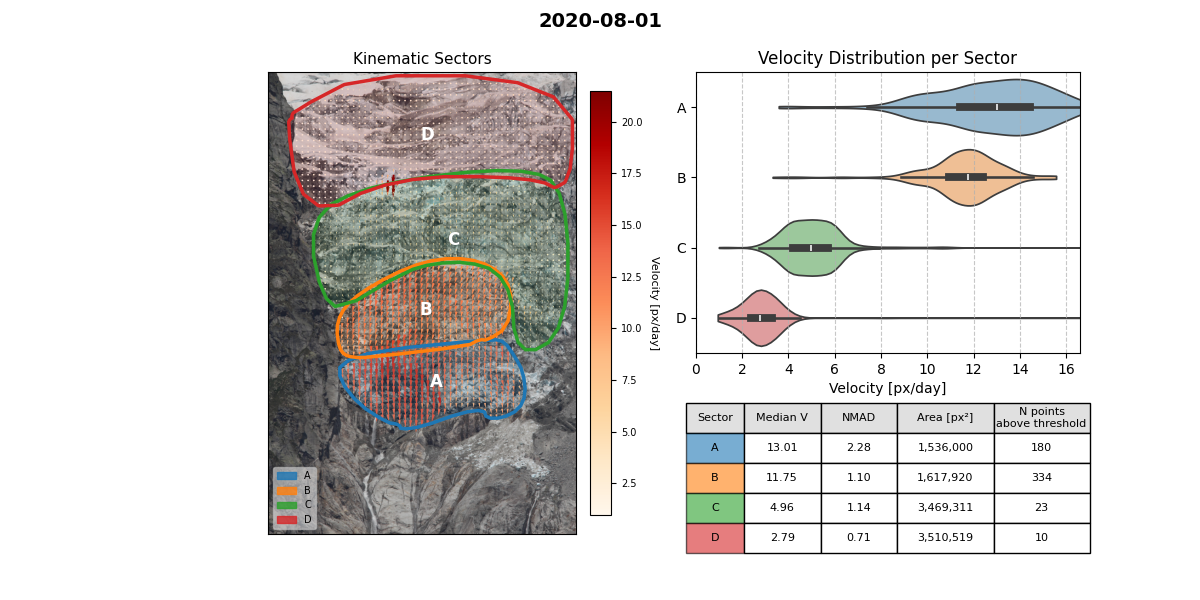

In [8]:
# --- Figure Layout ---
fig = plt.figure(figsize=figsize)
gs = gridspec.GridSpec(
    2,
    2,
    width_ratios=[1.2, 1],
    height_ratios=[1, 0.4],
    figure=fig,
    hspace=0.35,
    wspace=0.2,
)


# 1. Left Panel: Map (spans all rows)
map_ax = fig.add_subplot(gs[:, 0])
map_ax, map_legend_patches = plot_sectors(
    sectors=sectors,
    img=img,
    velocity_df=pts,
    sector_colors=colors,
    add_sector_labels=True,
    title="Kinematic Sectors",
    ax=map_ax,
    img_kwargs=img_kwargs,
    velocity_cmap=velocity_cmap,
    quiver_kwargs=quiver_kwargs,
    scatter_kwargs=scatter_kwargs,
    sector_kwargs=sector_kwargs,
    sector_fill_kwargs=sector_fill_kwargs,
    sector_edge_kwargs=sector_edge_kwargs,
    label_kwargs=label_kwargs,
)
# If no image is passed, invert the y axis to keep the correct orientation of the sectors
if img is None:
    map_ax.invert_yaxis()

# Build current handles/labels preferring returned legend patches from plot_sectors
if "map_legend_patches" in globals() and map_legend_patches:
    handles = list(map_legend_patches)
    labels = [p.get_label() for p in handles]
else:
    handles, labels = map_ax.get_legend_handles_labels()
    handles = list(handles)
    labels = list(labels)

# Force bottom-left placement with smaller font and semi-transparent background
legend_kwargs = dict(loc="lower left", fontsize=7, framealpha=0.5)

# Recreate legend with anomaly included
map_legend = map_ax.legend(handles=handles, labels=labels, **legend_kwargs)

# If anomaly detection was successful and we have a valid anomaly geometry, we add it to the plot
plot_anomaly = False
if (
    plot_anomaly
    and anomaly_gdf is not None
    and not anomaly_gdf.empty
    and anomaly_gdf.is_valid.any()
):
    anomaly_color = "#d3ff0d"  # bright yellow-green
    anomaly_label = "Anomaly"

    # get the map axis from the previous plot and plot the anomaly geometry on top with a distinct color and label
    anom_geoms = anomaly_gdf[anomaly_gdf["sector"] == "anomaly"].union_all()
    anom_geoms = gpd.GeoSeries(anom_geoms)

    # Add the anomaly geometry to the map with a distinct color and label. Keep the facecolor transparent to only show the edge
    anom_geoms.plot(
        ax=map_ax,
        facecolor="none",
        edgecolor=anomaly_color,
        linewidth=2,
        label=anomaly_label,
    )

    # Add anomaly legend entry (avoid duplicates) but preserve existing legend entries
    anom_patch = mpatches.Patch(
        facecolor="none", edgecolor=anomaly_color, linewidth=2, label=anomaly_label
    )

    # Append anomaly patch if missing
    if anomaly_label not in labels:
        handles.append(anom_patch)
        labels.append(anom_patch.get_label())


# Right Panel: Combined distribution (violin) + boxplot per sector
ax_dist = fig.add_subplot(gs[0, 1])

if hasattr(colors, "items"):
    palette = {str(k): v for k, v in colors.items()}
else:
    palette = dict(colors)

order = [str(s) for s in unique_sectors] if "unique_sectors" in globals() else None


# Violin shows per-sector density (like histogram), boxplot overlays summary stats
sns.violinplot(
    data=pts,
    x="V",
    y="sector",
    hue="sector",
    palette=palette,  # solid colors, same as map
    ax=ax_dist,
    inner="box",
    cut=0,  # do not extend beyond data
    density_norm="area",
    dodge=False,
)

# Make violin fills transparent while keeping edges fully opaque
for poly in ax_dist.collections:
    if isinstance(poly, mpl.collections.PolyCollection):
        fc = poly.get_facecolor()
        fc[:, 3] = 0.5  # set alpha only on face, not edge
        poly.set_facecolor(fc)

# remove seaborn-created legend (we use map legend)
if ax_dist.get_legend() is not None:
    ax_dist.get_legend().remove()

# Add background grid for better readability
ax_dist.grid(True, which="major", axis="x", linestyle="--", alpha=0.7)

# Dynamically limit X-axis to the 98th percentile to exclude extreme outliers
all_velocities = pts["V"].dropna()
if not all_velocities.empty:
    x_max = float(np.percentile(all_velocities, 99.5))
    # keep a small padding and preserve negative minima if present
    x_min = min(float(all_velocities.min()), 0.0)
    ax_dist.set_xlim(x_min, x_max * 1.02)

ax_dist.set_title("Velocity Distribution per Sector")
ax_dist.set_xlabel(f"Velocity [{unit}/day]")
ax_dist.set_ylabel("")


# 4. Right Panel Bottom: Text Statistics Table
ax_stats = fig.add_subplot(gs[1, 1])
ax_stats.axis("off")

# Prepare table data
header = ["Sector", "Median V", "NMAD", f"Area [{unit}²]", "N points\nabove threshold"]
relevant_sectors = sorted(pts["sector"].unique())
stats_data = []
for sec in relevant_sectors:
    row = sectors[sectors["sector"] == sec]
    if row.empty:
        continue
    row = row.iloc[0]
    nmad = row.get("v_nmad", np.nan)
    stats_data.append(
        [
            sec,
            f"{row['v_median']:.2f}",
            f"{nmad:.2f}",
            f"{int(row['area_px2']):,}",
            f"{int(row['pts_high'])}",
        ]
    )


# Render table
if stats_data:
    table = ax_stats.table(
        cellText=stats_data,
        colLabels=header,
        loc="center",
        cellLoc="center",
        colWidths=[0.15, 0.2, 0.2, 0.25, 0.25],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.8)

    # Style headers and cells
    for (i, j), cell in table.get_celld().items():
        if i == 0:
            cell.set_facecolor("#e0e0e0")
            cell.set_text_props()
        else:
            # Color the sector letter cell with the sector color
            if j == 0:
                sec_label = stats_data[i - 1][0]
                c = colors.get(sec_label, "#ffffff")
                cell.set_facecolor(c)
                cell.set_text_props(color="black")
                cell.set_alpha(0.6)


# Set global title for the entire figure
fig.suptitle(f"{date}", fontsize=14, weight="bold", y=0.98)

In [9]:
plt.savefig(
    f"{base_name}_{date}.png",
    dpi=dpi,
    bbox_inches="tight",
)

In [ ]:
# # hazard matrix is a 3x3 matrix that stores the level of hazard for each sector A, B, C (D is not negleted).
# # It has two dimensions: Velocity and and the rate of velocity increase compared to one week before (the acceleration).
# # The level of hazard is represented as an integer from 1 (low hazard) to 3 (high hazard).

# # The level of hazard is determined with the following thresholds:

# # Velocity thresholds (in px/day):
# velocity_thresholds = {
#     "A": [10, 13],  # Low: < 10, Medium: 10-13, High: > 13
#     "B": [7, 10],  # Low: < 7, Medium: 7-10, High: > 10
#     "C": [3, 6],  # Low: < 3, Medium: 3-6, High: >  6
#     "D": [3, 6],  # Low: < 3, Medium: 3-6, High: >  6
# }

# # Also the level of hazard for each sector is increased if there was a significant identified acceleration (and/or increase of area) in the last week.
# days_before_to_check = 7

# # Acceleration thresholds (in px/day^2):
# # Filling with defaults: 0 (stable/decelerating) and 0.1 (moderate acceleration) as boundaries
# default_acc_thresholds = [0.05, 0.2]
# acceleration_thresholds = {
#     "A": default_acc_thresholds,
#     "B": default_acc_thresholds,
#     "C": default_acc_thresholds,
# }

# # Area thresholds (in 10e6 px^2):
# # area_thresholds = {
# #     "A": [1.7, 2.5],  # Low: <, Medium: -, High: >
# #     "B": [],  # Low: <, Medium: -, High: >
# #     "C": [],  # Low: <, Medium: -, High: >
# # }
# # area_thresholds = {k: [v[0] * 1e6, v[1] * 1e6] for k, v in area_thresholds.items()}

# # The overall hazard level is determined as the maximum hazard level among all sectors.
# overall_hazard_level = 1

In [11]:
# def get_class(value, thresholds):
#     """Return 0 (Low), 1 (Medium), or 2 (High) based on thresholds [t1, t2]."""
#     if value < thresholds[0]:
#         return 0
#     elif value <= thresholds[1]:
#         return 1
#     else:
#         return 2


# # The hazard matrix values is defined as follows:
# # x axis: acceleration
# # y axis: velocity
# hazard_matrix_values = np.array(
#     [
#         [1, 1, 2],  # V=Low:  Acc (Low->1, Med->1, High->2)
#         [1, 2, 3],  # V=Med:  Acc (Low->1, Med->2, High->3)
#         [3, 3, 3],  # V=High: Acc (Low->3, Med->3, High->3) ~ Conservative approach
#     ]
# )

# # Define colors for hazard levels: 1=Green, 2=Yellow, 3=Red
# hazard_colors = {1: "#2ecc71", 2: "#f1c40f", 3: "#e74c3c"}
# hazard_labels = {1: "Low", 2: "Medium", 3: "High"}


# # Prepare DataFrames
# df_curr = data["sectors"].set_index("sector")
# if data_before is not None and "sectors" in data_before:
#     df_prev = data_before["sectors"].set_index("sector")
# else:
#     df_prev = pd.DataFrame()

# sector_hazards = []
# for sector in ["A", "B", "C"]:
#     if sector not in df_curr.index:
#         continue

#     # 1. Get Velocity
#     v_curr = df_curr.loc[sector, "v_median"]

#     # 2. Get Acceleration
#     v_prev = np.nan
#     acc = 0.0
#     if sector in df_prev.index:
#         v_prev = df_prev.loc[sector, "v_median"]
#         acc = (v_curr - v_prev) / days_before_to_check

#     # 3. Determine Classes
#     v_thresh = velocity_thresholds[sector]
#     a_thresh = acceleration_thresholds[sector]

#     v_class = get_class(v_curr, v_thresh)
#     a_class = get_class(acc, a_thresh)

#     # 4. Determine Combined hazard Level (1, 2, 3)
#     hazard_level = hazard_matrix_values[v_class, a_class]

#     sector_hazards.append(
#         {
#             "sector": sector,
#             "v_val": v_curr,
#             "v_prev": v_prev,
#             "a_val": acc,
#             "v_class": v_class,
#             "a_class": a_class,
#             "v_thresh": v_thresh,
#             "a_thresh": a_thresh,
#             "hazard_level": hazard_level,
#         }
#     )
